# Customer Churn EDA

통신사 고객 이탈(Churn) 예측 데이터 탐색적 분석

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 스타일 설정
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')
sns.set_palette("husl")
%matplotlib inline

DATA_DIR = Path("data")
train = pd.read_csv(DATA_DIR / "train.csv")
print(f"데이터 shape: {train.shape}")
train.head()

데이터 shape: (594194, 21)


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


**분석**  
학습 데이터는 약 59만 4천 행, 21개 컬럼으로 구성되어 있다. `id`, 인구통계(성별·시니어·배우자·부양가족), 가입 기간(`tenure`), 서비스 옵션(전화·인터넷·부가서비스), 계약·결제·요금 정보, 그리고 타깃 `Churn`이 포함되어 있다. 상위 5행만 보면 수치형(tenure, MonthlyCharges, TotalCharges)과 범주형이 혼재해 있음을 확인할 수 있다.

## 1. 기본 정보 & 결측치

In [2]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  str    
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  str    
 4   Dependents        594194 non-null  str    
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  str    
 7   MultipleLines     594194 non-null  str    
 8   InternetService   594194 non-null  str    
 9   OnlineSecurity    594194 non-null  str    
 10  OnlineBackup      594194 non-null  str    
 11  DeviceProtection  594194 non-null  str    
 12  TechSupport       594194 non-null  str    
 13  StreamingTV       594194 non-null  str    
 14  StreamingMovies   594194 non-null  str    
 15  Contract          594194 non-null  str    
 16  PaperlessBilling  594194 non-nu

**분석**  
`info()`로 보면 대부분의 컬럼이 object(범주형) 또는 int64/float64이다. `TotalCharges`는 CSV에서 공백으로 들어올 수 있어 object로 읽혔을 가능성이 있으므로, 결측·공백 처리 후 숫자로 변환이 필요하다. non-null count로 결측 여부를 확인할 수 있다.

In [3]:
# 결측치 확인 (공백 문자열 포함)
missing = train.isnull().sum()
# TotalCharges는 CSV에서 빈 문자열로 올 수 있음
if 'TotalCharges' in train.columns:
    blank_total = (train['TotalCharges'] == '').sum()
    if blank_total > 0:
        missing['TotalCharges'] = blank_total
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing) > 0:
    print("결측/공백이 있는 컬럼:")
    display(missing.to_frame('count'))
else:
    print("결측치 없음.")

결측치 없음.


**분석**  
결측/공백이 있는 컬럼이 있다면 위 표에 개수가 나온다. Churn 데이터에서 `TotalCharges`는 신규 가입(tenure=0 또는 매우 짧을 때)에서 빈 문자열로 들어오는 경우가 많다. 결측이 많으면 삭제·대체(예: 0 또는 중앙값) 등 전략을 정해야 한다.

In [4]:
# TotalCharges가 문자열인 경우 숫자로 변환 (공백은 NaN)
if train['TotalCharges'].dtype == object or (train['TotalCharges'] == '').any():
    train['TotalCharges'] = pd.to_numeric(train['TotalCharges'], errors='coerce')
train.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,594194.0,NaN,NaN,NaN,297096.5,171529.177263,0.0,148548.25,297096.5,445644.75,594193.0
gender,594194,2,Female,298738,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,594194.0,NaN,NaN,NaN,0.114102,0.317936,0.0,0.0,0.0,0.0,1.0
Partner,594194,2,Yes,309554,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,594194,2,No,414362,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,594194.0,NaN,NaN,NaN,36.577258,25.061922,1.0,12.0,35.0,62.0,72.0
PhoneService,594194,2,Yes,557893,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,594194,3,No,283384,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,594194,3,Fiber optic,272386,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,594194,3,No,289474,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**분석**  
`describe()`로 수치형 변수의 개수, 평균, 표준편차, 최소·최대, 사분위수를 확인한다. `tenure`는 0~72개월, `MonthlyCharges`·`TotalCharges`는 요금 단위로 해석하면 된다. `TotalCharges`가 NaN으로 나온 행이 있다면 결측 처리 후 다시 요약 통계를 보는 것이 좋다. 수치형 분포가 치우쳐 있으면 로그 변환·구간화를 고려할 수 있다.

## 2. 타깃(Churn) 분포

In [5]:
churn_counts = train['Churn'].value_counts()
churn_pct = train['Churn'].value_counts(normalize=True).mul(100).round(2)
pd.DataFrame({'count': churn_counts, 'percent': churn_pct})

,count,percent
Churn,,
No,460377,77.48
Yes,133817,22.52


**분석**  
타깃(Churn)의 Yes/No 비율을 보면 **클래스 불균형** 정도를 파악할 수 있다. Yes 비율이 지나치게 작으면(예: 5% 미만) 재표본추출(SMOTE 등) 또는 가중치 부여를, 비슷하면(예: 20~40%) 그대로 모델링해도 된다. ROC AUC 평가이므로 확률 예측이 중요하다.

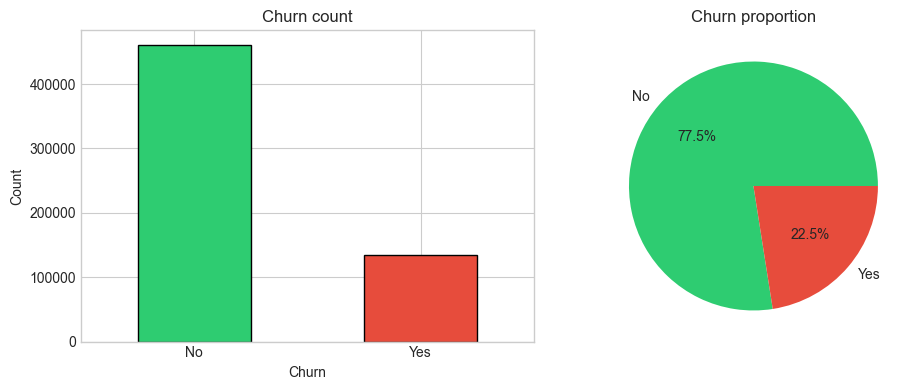

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
churn_counts.plot(kind='bar', ax=ax[0], color=['#2ecc71', '#e74c3c'], edgecolor='black')
ax[0].set_title('Churn count')
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=0)
ax[0].set_ylabel('Count')
churn_counts.plot(kind='pie', ax=ax[1], autopct='%1.1f%%', labels=['No', 'Yes'], colors=['#2ecc71', '#e74c3c'])
ax[1].set_title('Churn proportion')
ax[1].set_ylabel('')
plt.tight_layout()
plt.show()

**분석**  
왼쪽 막대 그래프는 Churn Yes/No의 **절대 개수**, 오른쪽 파이 차트는 **비율**을 보여 준다. 이탈(Yes) 비율이 어느 정도인지 한눈에 파악할 수 있으며, 이후 범주형 변수별 Churn 비율과 비교할 때 기준이 된다.

## 3. 수치형 변수

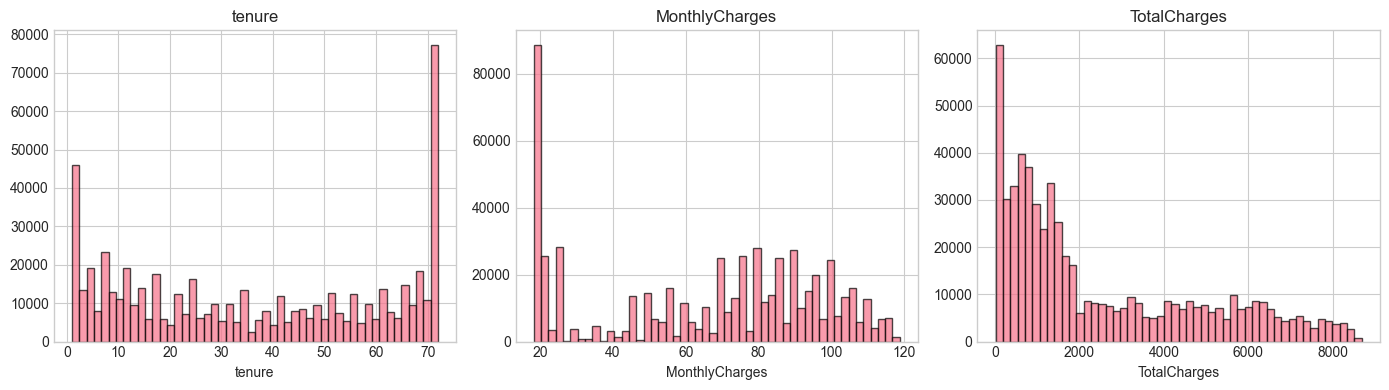

In [7]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
num_cols = [c for c in num_cols if c in train.columns]
train_num = train[num_cols].copy()
# NaN 제거 후 히스토그램
train_num_clean = train_num.dropna()
fig, axes = plt.subplots(1, len(num_cols), figsize=(14, 4))
for i, col in enumerate(num_cols):
    axes[i].hist(train_num_clean[col], bins=50, edgecolor='black', alpha=0.7)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
plt.tight_layout()
plt.show()

C:\Users\Dogeol\AppData\Local\Temp\ipykernel_20388\2859199260.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train.dropna(subset=[col]), x='Churn', y=col, ax=axes[i], palette=['#2ecc71', '#e74c3c'])
C:\Users\Dogeol\AppData\Local\Temp\ipykernel_20388\2859199260.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train.dropna(subset=[col]), x='Churn', y=col, ax=axes[i], palette=['#2ecc71', '#e74c3c'])
C:\Users\Dogeol\AppData\Local\Temp\ipykernel_20388\2859199260.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train.drop

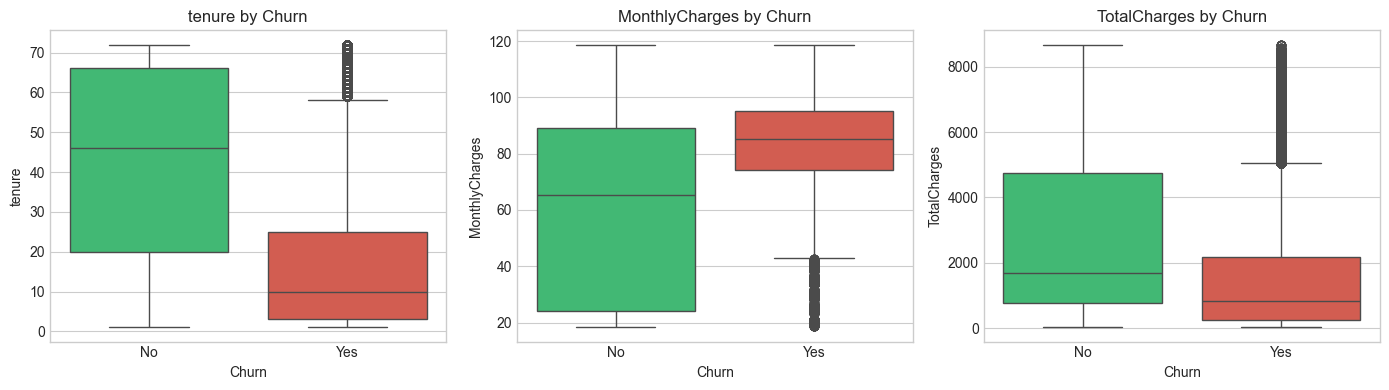

In [8]:
# 수치형 변수 vs Churn (박스플롯)
train['Churn_bin'] = (train['Churn'] == 'Yes').astype(int)
fig, axes = plt.subplots(1, len(num_cols), figsize=(14, 4))
for i, col in enumerate(num_cols):
    sns.boxplot(data=train.dropna(subset=[col]), x='Churn', y=col, ax=axes[i], palette=['#2ecc71', '#e74c3c'])
    axes[i].set_title(f'{col} by Churn')
plt.tight_layout()
plt.show()

**분석**  
`tenure`는 보통 0 근처와 중간 구간에 피크가 있을 수 있고, `MonthlyCharges`는 요금제에 따라 여러 봉우리를 보일 수 있다. `TotalCharges`는 tenure·월요금과 맞물려 오른쪽으로 꼬리가 긴 분포일 수 있다. 이상치나 0이 많으면 전처리(클리핑, 구간화 등)를 고려한다.

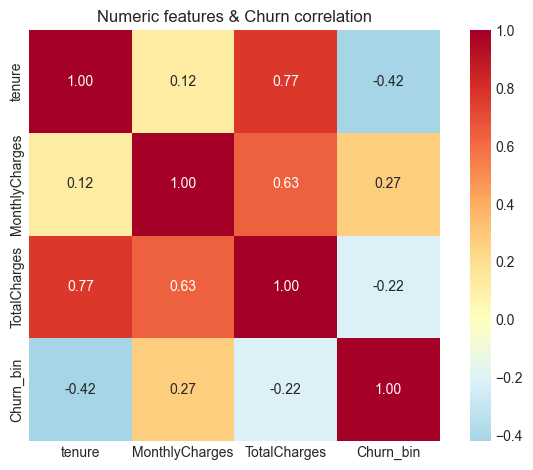

In [9]:
# 수치형 변수 간 상관관계
corr_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_bin']
corr_cols = [c for c in corr_cols if c in train.columns]
corr = train[corr_cols].corr()
sns.heatmap(corr, annot=True, cmap='RdYlBu_r', center=0, fmt='.2f', square=True)
plt.title('Numeric features & Churn correlation')
plt.tight_layout()
plt.show()

**분석**  
Churn Yes 그룹은 **tenure가 짧고**, **TotalCharges가 낮은** 경향이 있을 수 있다(신규 가입 이탈). MonthlyCharges는 두 그룹 차이가 상대적으로 작을 수 있다. 박스플롯에서 중앙값·사분위수·이상치를 비교해 변수별로 이탈 그룹과의 차이를 해석할 수 있다.

## 4. 범주형 변수 & Churn 비율

**분석**  
`tenure`와 `TotalCharges`는 서로 강한 양의 상관이 있을 수 있다(가입 기간이 길수록 누적 요금 증가). **Churn_bin**과의 상관이 음수이면(tenure, TotalCharges) 가입 기간·누적 요금이 낮을수록 이탈 가능성이 높다는 해석이 가능하다. 다중공선성이 크면 일부 수치형만 사용하거나 정규화를 고려한다.

In [10]:
cat_cols = [c for c in train.columns if c not in ['id', 'Churn', 'Churn_bin'] and train[c].dtype == object]
cat_cols = [c for c in cat_cols if train[c].nunique() <= 20]  # 카디널리티 제한
print("범주형 컬럼:", cat_cols)

범주형 컬럼: []


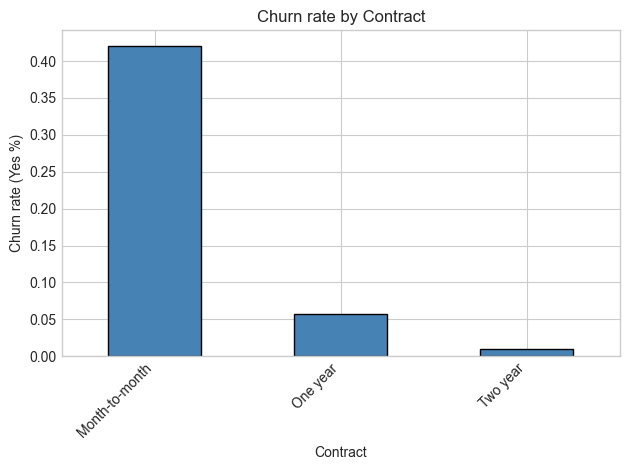

In [11]:
# 범주별 Churn 비율 (Yes 비율)
churn_rate = train.groupby('Contract')['Churn_bin'].mean().sort_values(ascending=False)
churn_rate.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Churn rate by Contract')
plt.ylabel('Churn rate (Yes %)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**분석**  
범주형 변수는 인코딩(원핫, 타깃 인코딩 등)이 필요하다. 카디널리티가 너무 큰 컬럼은 제외했으므로, 위 목록을 기준으로 Churn과의 관계를 보면 모델에 넣을 feature 후보를 정하는 데 도움이 된다.

In [12]:
# 주요 범주형 변수별 Churn 비율 요약
key_cats = ['Contract', 'InternetService', 'PaymentMethod', 'Partner', 'Dependents']
key_cats = [c for c in key_cats if c in train.columns]
for col in key_cats:
    rate = train.groupby(col)['Churn_bin'].agg(['mean', 'count']).round(4)
    rate.columns = ['churn_rate', 'count']
    rate = rate.sort_values('churn_rate', ascending=False)
    print(f"\n--- {col} ---")
    display(rate)


--- Contract ---


,churn_rate,count
Contract,,
Month-to-month,0.4205,298918
One year,0.0576,108333
Two year,0.0100,186943



--- InternetService ---


,churn_rate,count
InternetService,,
Fiber optic,0.4154,272386
DSL,0.1031,181081
No,0.0143,140727



--- PaymentMethod ---


,churn_rate,count
PaymentMethod,,
Electronic check,0.4891,215372
Mailed check,0.0797,123757
Bank transfer (automatic),0.0771,121360
Credit card (automatic),0.0693,133705



--- Partner ---


,churn_rate,count
Partner,,
No,0.3246,284640
Yes,0.1338,309554



--- Dependents ---


,churn_rate,count
Dependents,,
No,0.2914,414362
Yes,0.0728,179832


**분석**  
**Contract**별로 Churn 비율이 뚜렷이 다르다. Month-to-month가 가장 높고, Two year가 가장 낮은 패턴이 typical하다. 계약 기간이 짧을수록 이탈이 많다는 해석이 가능하므로, Contract는 중요한 예측 변수로 활용하는 것이 좋다.

## 5. Tenure(가입기간) vs Churn

**분석**  
각 범주별 **churn_rate**가 높은 순으로 정렬되어 있다. InternetService에서 Fiber optic, PaymentMethod에서 Electronic check 등이 상대적으로 이탈 비율이 높을 수 있다. Partner/Dependents가 No인 경우가 Yes인 경우보다 이탈률이 높은지도 확인할 수 있다. 표에서 count가 너무 작은 범주는 노이즈일 수 있으니 주의한다.

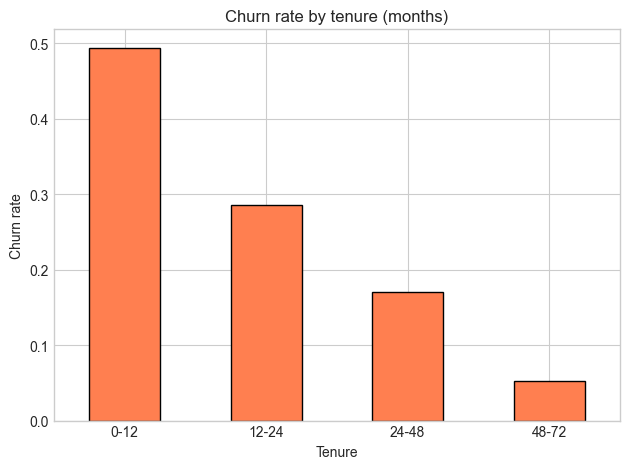

In [13]:
# 가입 기간 구간별 Churn 비율
train['tenure_bin'] = pd.cut(train['tenure'], bins=[0, 12, 24, 48, 72, 100], labels=['0-12', '12-24', '24-48', '48-72', '72+'])
rate_by_tenure = train.groupby('tenure_bin', observed=True)['Churn_bin'].mean()
rate_by_tenure.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Churn rate by tenure (months)')
plt.ylabel('Churn rate')
plt.xlabel('Tenure')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. 요약

**분석**  
가입 기간이 **짧을수록(0–12개월)** Churn 비율이 높고, **길어질수록(48개월 이상)** 낮아지는 경향이 typical하다. 신규 가입자 이탈이 많다는 비즈니스 해석과 맞으며, tenure(또는 tenure_bin)를 그대로 또는 구간화해 모델에 넣는 것이 유리하다.

In [14]:
print("=== EDA 요약 ===\n")
print(f"• 샘플 수: {len(train):,}, 컬럼 수: {len(train.columns)}")
print(f"• 타깃 불균형: Churn Yes {train['Churn_bin'].mean():.2%}")
print(f"• 수치형: tenure, MonthlyCharges, TotalCharges (TotalCharges 결측 확인 필요)")
print("• Churn과 상관 높을 수 있는 요인: Contract(Month-to-month), tenure 짧을수록, InternetService(Fiber), PaymentMethod 등")

=== EDA 요약 ===

• 샘플 수: 594,194, 컬럼 수: 23
• 타깃 불균형: Churn Yes 22.52%
• 수치형: tenure, MonthlyCharges, TotalCharges (TotalCharges 결측 확인 필요)
• Churn과 상관 높을 수 있는 요인: Contract(Month-to-month), tenure 짧을수록, InternetService(Fiber), PaymentMethod 등


**분석**  
EDA를 바탕으로 **모델링 시 참고할 점**을 정리하면: 
(1) 타깃 불균형에 맞는 손실 함수 또는 샘플링 
(2) TotalCharges 결측 처리 및 수치형 스케일링
(3) Contract·InternetService·PaymentMethod·tenure 등 Churn과 상관 있는 변수 적극 활용
(4) ROC AUC를 높이기 위해 확률 예측 및 칼라이브레이션 검토가 유용하다